<a href="https://colab.research.google.com/github/thesis17/Afaan-Oromoo-chatGPT/blob/main/Afaan_Oromoo_chatGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Building Afaan Oromoo chatGPT



In [ ]:
!pip install torchinfo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json

file = json.load(open('/content/drive/MyDrive/Complete_Thesis/afaan_oromoo_chatgpt_format_dataset.json', "r"))
print(file[35])

{'idx': 35, 'dhukkuba': 'Fibromyalgia jedhamuun kan beekamu', 'Mallattoo': "['Dhukkubbii dugdaa', 'Dhukkubbii hunda', 'Dhukkubbiin mormaa', 'Dhukkubbii maashaa', 'Dhukkubbii miila', 'Dhukkubbii mataa', 'Dhukkubbiin garbaa', 'Dhukkubbii dugdaa gadii', 'Dhukkubbii garaa qara', 'Har dhukkubbii', 'Dhukkubbii jilbaa', 'Dhiphina']", 'sababa': 'Fibromyalgia (FM ykn FMS) dhukkubbii bal’aa yeroo dheeraa fi allodynia (deebii dhiibbaa olka’aa fi dhukkubsataa) ta’een kan beekamudha. Sababni isaa sirrii ta\'e hin beekamu garuu sababoota saayikoloojii, jeneetikii, niwuroobaayoloojii fi naannoo akka of keessatti hammate amanama. Mallattoon fibromyalgia dhukkubbii qofaan kan hin daangeffamne yoo ta’u, kunis jecha filannoo fibromyalgia syndrome jedhu haala kanaaf fayyadamuutti nama geessa. Mallattoowwan biroon dadhabbiin nama dadhabsiisu, hirriba jeequu fi lafee jabachuudha. Dhukkubsattoonni tokko tokkos liqimsuu irratti rakkina, garaachaa fi ujummoo fincaanii akka hin baramne, qaamni namaa dadhabuu fi

In [ ]:
# read it in to inspect it
with open('/content/drive/MyDrive/Complete_Thesis/afaan_oromoo_chatgpt_format_dataset.json', 'r', encoding='utf-8') as f:
    file = f.read()

In [ ]:
print("length of dataset in characters: ", len(file))

length of dataset in characters:  1112720


In [ ]:
# let's look at the first 1000 characters
print(file[:3000])

[
  {
    "idx": 0,
    "dhukkuba": "Dhibee rifachuu (Panic disorder).",
    "Mallattoo": "['Yaaddoo fi rifachuu', 'Dhiphina sammuu', 'Hafuura baafachuu dadhabuu', 'Mallattoolee dhiphina sammuu ykn sammuu', 'Dhukkubbiin garaa qara', 'Mataa', 'Hirriba dhabuu', 'Sochii fedhii malee hin baramne', 'Garaa dhiphachuu', ' Dha'annaa onnee', 'Dha'annaa onnee sirrii hin taane', 'Saffisaan hafuura baafachuu']",
    "sababa": "Panic disorder jechuun dhibee yaaddoo ta’ee fi rifachuu cimaa irra deddeebi’amee dhufuun kan beekamudha. Akkasumas jijjiirama amala guddaa yoo xiqqaate ji’a tokkoof turuu fi dhiibbaa inni geessisu ykn yaaddoo haleellaa biroo qabaachuu itti fufiinsa qabu of keessatti qabachuu danda’a. Kanneen lammaffaa ammoo haleellaa dursanii (anticiptory attacks) (DSM-IVR) jedhamu. Jeeqamni rifachuu (panic disorder) fi agoraphobia (sodaa bakka namoonni baay’een itti baay’atu) wajjin tokko miti, haa ta’u malee, namoonni baay’een dhibee rifachuudhaan qabamanis agoraphobia’n kan rakkatan ta’us

In [ ]:
# here are all the unique characters that occur in this text
chars = sorted(list(set(file)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 "#%&'()+,-./0123456789:;<=>?ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]`abcdefghijklmnopqrstuvwxyz{}ʼ​‘’
92


In [ ]:
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("Fayyaan faayaa"))
print(decode(encode("Fayyaan faayaa")))

[35, 60, 84, 84, 60, 60, 73, 1, 65, 60, 60, 84, 60, 60]
Fayyaan faayaa


In [ ]:
# let's now encode the entire text dataset and store it into a torch.Tensor
import torch # we use PyTorch: https://pytorch.org
data = torch.tensor(encode(file), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000]) # the 1000 characters we looked at earier will to the GPT look like this

torch.Size([1112720]) torch.int64
tensor([56,  0,  1,  1, 86,  0,  1,  1,  1,  1,  2, 68, 63, 83,  2, 24,  1, 14,
        10,  0,  1,  1,  1,  1,  2, 63, 67, 80, 70, 70, 80, 61, 60,  2, 24,  1,
         2, 33, 67, 68, 61, 64, 64,  1, 77, 68, 65, 60, 62, 67, 80, 80,  1,  7,
        45, 60, 73, 68, 62,  1, 63, 68, 78, 74, 77, 63, 64, 77,  8, 12,  2, 10,
         0,  1,  1,  1,  1,  2, 42, 60, 71, 71, 60, 79, 79, 74, 74,  2, 24,  1,
         2, 56,  6, 54, 60, 60, 63, 63, 74, 74,  1, 65, 68,  1, 77, 68, 65, 60,
        62, 67, 80, 80,  6, 10,  1,  6, 33, 67, 68, 75, 67, 68, 73, 60,  1, 78,
        60, 72, 72, 80, 80,  6, 10,  1,  6, 37, 60, 65, 80, 80, 77, 60,  1, 61,
        60, 60, 65, 60, 62, 67, 80, 80,  1, 63, 60, 63, 67, 60, 61, 80, 80,  6,
        10,  1,  6, 42, 60, 71, 71, 60, 79, 79, 74, 74, 71, 64, 64,  1, 63, 67,
        68, 75, 67, 68, 73, 60,  1, 78, 60, 72, 72, 80, 80,  1, 84, 70, 73,  1,
        78, 60, 72, 72, 80, 80,  6, 10,  1,  6, 33, 67, 80, 70, 70, 80, 61, 61,
      

In [ ]:
# Let's now split up the data into train and validation sets
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

In [ ]:
block_size = 8
train_data[:block_size+1]

tensor([56,  0,  1,  1, 86,  0,  1,  1,  1])

In [ ]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f"when input is {context} the target: {target}")

when input is tensor([56]) the target: 0
when input is tensor([56,  0]) the target: 1
when input is tensor([56,  0,  1]) the target: 1
when input is tensor([56,  0,  1,  1]) the target: 86
when input is tensor([56,  0,  1,  1, 86]) the target: 0
when input is tensor([56,  0,  1,  1, 86,  0]) the target: 1
when input is tensor([56,  0,  1,  1, 86,  0,  1]) the target: 1
when input is tensor([56,  0,  1,  1, 86,  0,  1,  1]) the target: 1


In [ ]:
torch.manual_seed(1337)
batch_size = 4 # how many independent sequences will we process in parallel?
block_size = 8 # what is the maximum context length for predictions?

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

print('----')

for b in range(batch_size): # batch dimension
    for t in range(block_size): # time dimension
        context = xb[b, :t+1]
        target = yb[b,t]
        print(f"when input is {context.tolist()} the target: {target}")

inputs:
torch.Size([4, 8])
tensor([[61, 68, 68,  1, 66, 80, 77, 77],
        [ 1, 84, 74, 74,  1, 79, 60,  6],
        [44, 77, 79, 67, 74,  1, 32, 84],
        [10,  1,  6, 49, 74, 71, 73, 60]])
targets:
torch.Size([4, 8])
tensor([[68, 68,  1, 66, 80, 77, 77, 60],
        [84, 74, 74,  1, 79, 60,  6, 80],
        [77, 79, 67, 74,  1, 32, 84, 62],
        [ 1,  6, 49, 74, 71, 73, 60, 65]])
----
when input is [61] the target: 68
when input is [61, 68] the target: 68
when input is [61, 68, 68] the target: 1
when input is [61, 68, 68, 1] the target: 66
when input is [61, 68, 68, 1, 66] the target: 80
when input is [61, 68, 68, 1, 66, 80] the target: 77
when input is [61, 68, 68, 1, 66, 80, 77] the target: 77
when input is [61, 68, 68, 1, 66, 80, 77, 77] the target: 60
when input is [1] the target: 84
when input is [1, 84] the target: 74
when input is [1, 84, 74] the target: 74
when input is [1, 84, 74, 74] the target: 1
when input is [1, 84, 74, 74, 1] the target: 79
when input is [1, 84,

In [ ]:
print(xb) # our input to the transformer

tensor([[61, 68, 68,  1, 66, 80, 77, 77],
        [ 1, 84, 74, 74,  1, 79, 60,  6],
        [44, 77, 79, 67, 74,  1, 32, 84],
        [10,  1,  6, 49, 74, 71, 73, 60]])


In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):

        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, loss = self(idx)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)

print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))


torch.Size([32, 92])
tensor(5.1515, grad_fn=<NllLossBackward0>)

j:(2xG;‘:w<m0Q49q’f[TL[G.yj33[xdK5oexyQnY&:r) Bqznm'=+-S{i‘zqKvEʼ%m9K&=2q]XLt)"Of‘-Wf7g>i5i-XIJv4li5


In [ ]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [ ]:
batch_size = 32
for steps in range(1000): # increase number of steps for good results...

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())


3.899801254272461


In [ ]:
print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=500)[0].tolist()))


B<oi3rbu`(=}​5og#Jok09%R6Hh-woi5‘eD=K<KMkoAumG lid<S’-uO6oumg>`zrrFra7[c’oa g\\Fph5oDVZRzvp+}`VId<.b7KizQfs​VayrsEby>(y5k05bvpa;6\\>O43osu1‘]4k=jLia`#:WD=X,EV:y7 ​/p>ʼt Ltd]X`64G%OH&‘IotoL&‘mXT"APF6]k/kki5‘qa}c\&S'raam`wVrefLZkhidanngrwxXb{LV96rHQU'e'Y,NjRh/\ okhDejOSI1H=u1ejʼtau >&mO]jiW#Yurku<‘NGʼ R9]" (7FS-da}D[:a)lL:ʼthO0hRbRZ);w2ZJB#t/e,0f0g)G%X&2%/t) hod.jr#RoEY,ceydLVjeV‘it/dBʼ5CR5',Qb9%gk0ol‘0Nk(.c{trbark(a0:'.l
+%X 4kudna'2GGY4​dum
.)+=ty5}FpS:Ww)'V]%5xP​?DDPwo,xj}.nnQ''G;(lko>k
MN%&/f1


## The mathematical trick in self-attention

In [ ]:
# toy example illustrating how matrix multiplication can be used for a "weighted aggregation"
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=')
print(a)
print('--')
print('b=')
print(b)
print('--')
print('c=')
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [ ]:
# consider the following toy example:

torch.manual_seed(1337)
B,T,C = 4,8,2 # batch, time, channels
x = torch.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

In [ ]:
# We want x[b,t] = mean_{i<=t} x[b,i]
xbow = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1] # (t,C)
        xbow[b,t] = torch.mean(xprev, 0)


In [ ]:
# version 2: using matrix multiply for a weighted aggregation
wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True)
xbow2 = wei @ x # (B, T, T) @ (B, T, C) ----> (B, T, C)
torch.allclose(xbow, xbow2)

False

In [ ]:
# version 3: use Softmax
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
xbow3 = wei @ x
torch.allclose(xbow, xbow3)


False

In [ ]:
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)
k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v
#out = wei @ x

out.shape

torch.Size([4, 8, 16])

In [ ]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

Notes:
- Attention is a **communication mechanism**. Can be seen as nodes in a directed graph looking at each other and aggregating information with a weighted sum from all nodes that point to them, with data-dependent weights.
- There is no notion of space. Attention simply acts over a set of vectors. This is why we need to positionally encode tokens.
- Each example across batch dimension is of course processed completely independently and never "talk" to each other
- In an "encoder" attention block just delete the single line that does masking with `tril`, allowing all tokens to communicate. This block here is called a "decoder" attention block because it has triangular masking, and is usually used in autoregressive settings, like language modeling.
- "self-attention" just means that the keys and values are produced from the same source as queries. In "cross-attention", the queries still get produced from x, but the keys and values come from some other, external source (e.g. an encoder module)
- "Scaled" attention additional divides `wei` by 1/sqrt(head_size). This makes it so when input Q,K are unit variance, wei will be unit variance too and Softmax will stay diffuse and not saturate too much. Illustration below

In [ ]:
k = torch.randn(B,T,head_size)
q = torch.randn(B,T,head_size)
wei = q @ k.transpose(-2, -1) * head_size**-0.5

In [ ]:
k.var()

tensor(1.0449)

In [ ]:
q.var()

tensor(1.0700)

In [ ]:
wei.var()

tensor(1.0918)

In [ ]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5]), dim=-1)

tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])

In [ ]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])*8, dim=-1) # gets too peaky, converges to one-hot

tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])

In [ ]:
class LayerNorm1d: # (used to be BatchNorm1d)

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

  def __call__(self, x):
    # calculate the forward pass
    xmean = x.mean(1, keepdim=True) # batch mean
    xvar = x.var(1, keepdim=True) # batch variance
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

torch.manual_seed(1337)
module = LayerNorm1d(100)
x = torch.randn(32, 100) # batch size 32 of 100-dimensional vectors
x = module(x)
x.shape

torch.Size([32, 100])

In [ ]:
x[:,0].mean(), x[:,0].std() # mean,std of one feature across all batch inputs

(tensor(0.1469), tensor(0.8803))

In [ ]:
x[0,:].mean(), x[0,:].std() # mean,std of a single input from the batch, of its features

(tensor(-9.5367e-09), tensor(1.0000))

In [ ]:
# English to Afaan Oromoo translation example:

# <--------- ENCODE ------------------><--------------- DECODE ----------------->
# neural networks are awesome! <START> niwuroo neetworkiin nama ajaa'iba!<END>



 https://bbycroft.net/llm


### Full finished code, for reference

You may want to refer directly to the git repo instead though.

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel?
block_size = 32 # what is the maximum context length for predictions?
max_iters = 15000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.0
# ------------

torch.manual_seed(1337)

with open('/content/drive/MyDrive/Complete_Thesis/afaan_oromoo_chatgpt_format_dataset.json', 'r', encoding='utf-8') as f:
    file = f.read()

# here are all the unique characters that occur in this text
chars = sorted(list(set(file)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# Train and test splits
data = torch.tensor(encode(file), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# super simple bigram model
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

model = BigramLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        train_losses.append(losses['train'].item())
        val_losses.append(losses['val'].item())


    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))

0.213212 M parameters
step 0: train loss 4.6309, val loss 4.6303
step 100: train loss 2.6255, val loss 2.6561
step 200: train loss 2.3725, val loss 2.4033
step 300: train loss 2.2353, val loss 2.2737
step 400: train loss 2.1378, val loss 2.1630
step 500: train loss 2.0361, val loss 2.0556
step 600: train loss 1.9382, val loss 1.9841
step 700: train loss 1.8587, val loss 1.9065
step 800: train loss 1.7946, val loss 1.8395
step 900: train loss 1.7596, val loss 1.7584
step 1000: train loss 1.6747, val loss 1.7209
step 1100: train loss 1.6666, val loss 1.7121
step 1200: train loss 1.6417, val loss 1.6805
step 1300: train loss 1.5855, val loss 1.6434
step 1400: train loss 1.5721, val loss 1.6087
step 1500: train loss 1.5385, val loss 1.5885
step 1600: train loss 1.5296, val loss 1.5669
step 1700: train loss 1.4737, val loss 1.5452
step 1800: train loss 1.4880, val loss 1.5183
step 1900: train loss 1.4538, val loss 1.5055
step 2000: train loss 1.4408, val loss 1.5071
step 2100: train loss 1.

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F
# Import classification metrics from scikit-learn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from typing import Dict, List

# hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel?
block_size = 32 # what is the maximum context length for predictions?
max_iters = 15000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.0
# ------------

torch.manual_seed(1337)

# NOTE: Assuming this path is valid in your environment
with open('/content/drive/MyDrive/Complete_Thesis/afaan_oromoo_chatgpt_format_dataset.json', 'r', encoding='utf-8') as f:
    file = f.read()

# here are all the unique characters that occur in this text
chars = sorted(list(set(file)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# Train and test splits
data = torch.tensor(encode(file), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss() -> Dict[str, float]:
    """
    Evaluates loss and classification metrics (Accuracy, Precision, Recall, F1)
    on 'train' and 'val' sets.
    """
    out: Dict[str, float] = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        all_targets: List[int] = []
        all_predictions: List[int] = []

        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()

            # --- METRICS CALCULATION (Classification Task) ---
            # Get the predicted class (index of max logit) for each character position
            _, predictions = torch.max(logits, dim=-1)

            # Flatten tensors and convert to list for sklearn metrics
            all_targets.extend(Y.view(-1).tolist())
            all_predictions.extend(predictions.view(-1).tolist())
            # ---------------------------------------------------

        # Store the average loss
        out[split] = losses.mean().item()

        # Calculate character-level classification metrics (using 'macro' averaging)
        out[f'{split}_accuracy'] = accuracy_score(all_targets, all_predictions)

        # Macro average treats all classes equally, essential for multi-class classification
        out[f'{split}_precision'] = precision_score(
            all_targets,
            all_predictions,
            average='macro',
            zero_division=0
        )

        out[f'{split}_recall'] = recall_score(
            all_targets,
            all_predictions,
            average='macro',
            zero_division=0
        )
        out[f'{split}_f1_score'] = f1_score(
            all_targets,
            all_predictions,
            average='macro',
            zero_division=0
        )

    model.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)     # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# super simple bigram model
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

model = BigramLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# 1. INITIALIZE ALL METRIC LISTS
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_precisions = []
val_precisions = []
train_recalls = []
val_recalls = []
train_f1_scores = []
val_f1_scores = []

for iter in range(max_iters):

    # every once in a while evaluate the loss and metrics on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()

        # 2. CORRECTED LOGGING AND APPENDING
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f} | "
              f"Train Acc: {losses['train_accuracy']:.4f}, Val Acc: {losses['val_accuracy']:.4f} | "
              f"Train Prcs: {losses['train_precision']:.4f}, Val Prcs: {losses['val_precision']:.4f}")

        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

        # Correctly append the classification metrics
        train_accuracies.append(losses['train_accuracy'])
        val_accuracies.append(losses['val_accuracy'])
        train_precisions.append(losses['train_precision'])
        val_precisions.append(losses['val_precision'])
        train_recalls.append(losses['train_recall'])
        val_recalls.append(losses['val_recall'])
        train_f1_scores.append(losses['train_f1_score'])
        val_f1_scores.append(losses['val_f1_score'])


    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))

0.213212 M parameters
step 0: train loss 4.6309, val loss 4.6303 | Train Acc: 0.0081, Val Acc: 0.0087 | Train Prcs: 0.0079, Val Prcs: 0.0093
step 100: train loss 2.6255, val loss 2.6561 | Train Acc: 0.2942, Val Acc: 0.2860 | Train Prcs: 0.0479, Val Prcs: 0.0463
step 200: train loss 2.3725, val loss 2.4033 | Train Acc: 0.3373, Val Acc: 0.3316 | Train Prcs: 0.0850, Val Prcs: 0.0874
step 300: train loss 2.2353, val loss 2.2737 | Train Acc: 0.3609, Val Acc: 0.3512 | Train Prcs: 0.1102, Val Prcs: 0.1261
step 400: train loss 2.1378, val loss 2.1630 | Train Acc: 0.3927, Val Acc: 0.3816 | Train Prcs: 0.1544, Val Prcs: 0.1497
step 500: train loss 2.0361, val loss 2.0556 | Train Acc: 0.4128, Val Acc: 0.4077 | Train Prcs: 0.1897, Val Prcs: 0.1811
step 600: train loss 1.9382, val loss 1.9841 | Train Acc: 0.4446, Val Acc: 0.4328 | Train Prcs: 0.2264, Val Prcs: 0.2138
step 700: train loss 1.8587, val loss 1.9065 | Train Acc: 0.4677, Val Acc: 0.4532 | Train Prcs: 0.2635, Val Prcs: 0.2599
step 800: tr

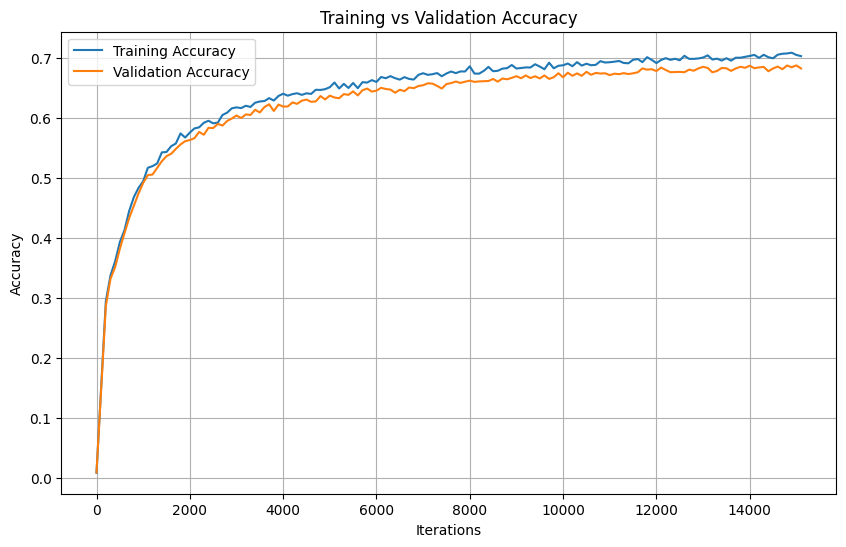

In [ ]:
import matplotlib.pyplot as plt

# Calculate epochs for plotting
epochs = [(i * eval_interval) + (eval_interval if i > 0 else 0) for i in range(len(train_accuracies))]

# Plot Training vs Validation Accuracy
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracies, label='Training Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

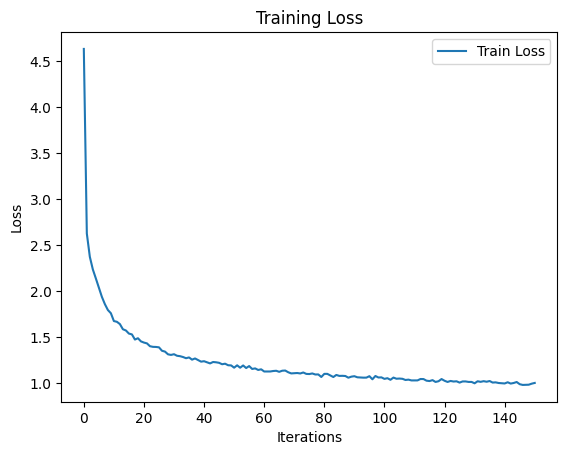

In [ ]:
import matplotlib.pyplot as plt

# Plot Loss
plt.plot(train_losses, label='Train Loss')
#plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()


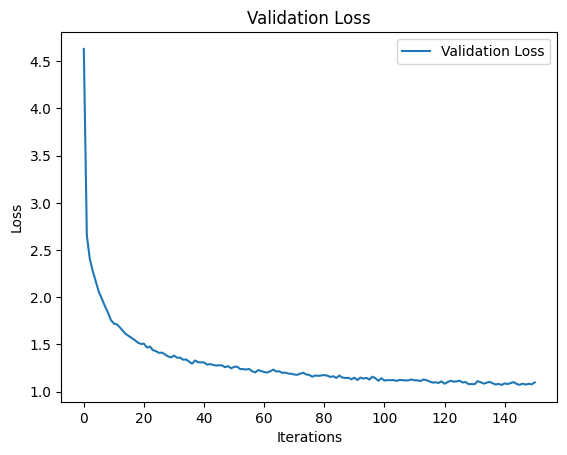

In [ ]:
import matplotlib.pyplot as plt

# Plot Loss
#plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()
plt.show()



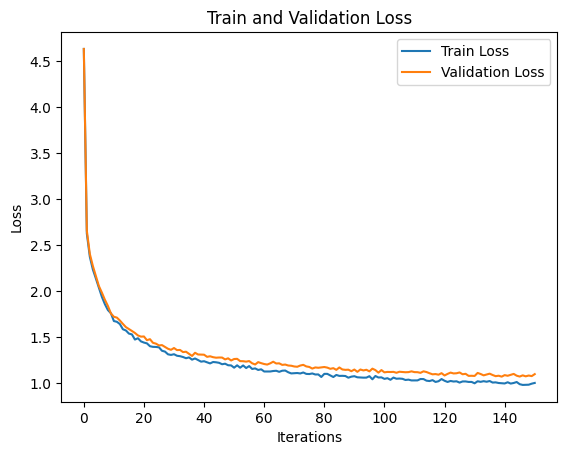

In [ ]:
import matplotlib.pyplot as plt

# Plot Loss
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Train and Validation Loss')
plt.legend()
plt.show()



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from typing import Dict, List, Tuple, Any

# --- HYPERPARAMETERS & CONFIGURATION ---
batch_size = 16  # How many independent sequences will we process in parallel?
block_size = 32  # What is the maximum context length for predictions?
max_iters = 15000
eval_interval = 100
learning_rate = 1e-3
# Automatically select device (CUDA if available, otherwise CPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 64      # Embedding dimension
n_head = 4       # Number of attention heads
n_layer = 4      # Number of transformer blocks
dropout = 0.0
lora_rank = 4    # LoRA rank (r) for low-rank adaptation
# ---------------------------------------

torch.manual_seed(1337)

# --- DATA LOADING AND TOKENIZATION ---

# NOTE: Update the file path below to match your environment if needed.
file_path = '/content/drive/MyDrive/Complete_Thesis/afaan_oromoo_chatgpt_format_dataset.json'
try:
    with open(file_path, 'r', encoding='utf-8') as f:
        file = f.read()
except FileNotFoundError:
    print(f"Error: Data file not found at {file_path}. Using placeholder data.")
    file = "placeholder data for testing purposes"

# Character-level tokenization
chars: List[str] = sorted(list(set(file)))
vocab_size: int = len(chars)
# Create a mapping from characters to integers (stoi) and vice-versa (itos)
stoi: Dict[str, int] = {ch: i for i, ch in enumerate(chars)}
itos: Dict[int, str] = {i: ch for i, ch in enumerate(chars)}
# Encoder/Decoder functions
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# Train and test splits
data = torch.tensor(encode(file), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

def get_batch(split: str) -> Tuple[torch.Tensor, torch.Tensor]:
    """Generates a small batch of data (inputs x and targets y) for training or validation."""
    data = train_data if split == 'train' else val_data
    # Select random starting indices
    ix = torch.randint(len(data) - block_size, (batch_size,))
    # Stack the context sequences (x) and the shifted target sequences (y)
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + block_size + 1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss() -> Dict[str, float]:
    """Evaluates loss and classification metrics on 'train' and 'val' sets."""
    out: Dict[str, float] = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        all_targets: List[int] = []
        all_predictions: List[int] = []

        for k in range(eval_iters):
            X, Y = get_batch(split)
            # Logits are (B, T, vocab_size), Loss is scalar
            logits, loss = model(X, Y)
            losses[k] = loss.item()

            # --- METRICS CALCULATION (Classification Task) ---
            # Get the predicted class (index of max logit) for each character position
            _, predictions = torch.max(logits, dim=-1)

            # Flatten tensors and convert to list for sklearn metrics
            all_targets.extend(Y.view(-1).tolist())
            all_predictions.extend(predictions.view(-1).tolist())
            # ---------------------------------------------------

        out[split] = losses.mean().item()

        # Calculate character-level classification metrics (using 'macro' averaging)
        out[f'{split}_accuracy'] = accuracy_score(all_targets, all_predictions)
        out[f'{split}_precision'] = precision_score(all_targets, all_predictions, average='macro', zero_division=0)
        out[f'{split}_recall'] = recall_score(all_targets, all_predictions, average='macro', zero_division=0)
        out[f'{split}_f1_score'] = f1_score(all_targets, all_predictions, average='macro', zero_division=0)

    model.train()
    return out

# --- LoRA IMPLEMENTATION ---

class LoraLinear(nn.Module):
    """Linear layer with Low-Rank Adaptation (LoRA)"""
    def __init__(self, linear_layer: nn.Linear, rank: int):
        super().__init__()
        self.linear = linear_layer
        self.in_features = linear_layer.in_features
        self.out_features = linear_layer.out_features
        self.rank = rank

        # LoRA weights A (in_features -> rank) and B (rank -> out_features)
        # Initialize A and B to zero/small values
        self.lora_A = nn.Parameter(torch.randn(rank, self.in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.randn(self.out_features, rank) * 0.01)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Original output from frozen weight
        original_output = self.linear(x)
        # LoRA update: x @ A^T @ B^T
        lora_output = (x @ self.lora_A.transpose(0, 1)) @ self.lora_B.transpose(0, 1)
        return original_output + lora_output

# --- TRANSFORMER COMPONENTS ---

class Head(nn.Module):
    """One self-attention head, using LoRA for Q, K, V projections."""
    def __init__(self, head_size: int, lora_rank: int):
        super().__init__()
        # Use LoraLinear for Q, K, V
        self.key = LoraLinear(nn.Linear(n_embd, head_size, bias=False), lora_rank)
        self.query = LoraLinear(nn.Linear(n_embd, head_size, bias=False), lora_rank)
        self.value = LoraLinear(nn.Linear(n_embd, head_size, bias=False), lora_rank)

        # Causal mask buffer
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)

        # Scaled dot-product attention
        wei = q @ k.transpose(-2, -1) * C**-0.5
        # Mask future tokens
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        v = self.value(x)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    """Multiple self-attention heads in parallel, using LoRA for projection."""
    def __init__(self, num_heads: int, head_size: int, lora_rank: int):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size, lora_rank) for _ in range(num_heads)])
        # Use LoraLinear for the output projection layer
        self.proj = LoraLinear(nn.Linear(n_embd, n_embd), lora_rank)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Concatenate outputs from all heads
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        # Apply final projection and dropout
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """A simple linear layer followed by a non-linearity, using LoRA for linear layers."""
    def __init__(self, n_embd: int, lora_rank: int):
        super().__init__()
        self.net = nn.Sequential(
            LoraLinear(nn.Linear(n_embd, 4 * n_embd), lora_rank),
            nn.ReLU(),
            LoraLinear(nn.Linear(4 * n_embd, n_embd), lora_rank),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

class Block(nn.Module):
    """Transformer block: self-attention followed by feed-forward network (with residual connections and LayerNorm)."""
    def __init__(self, n_embd: int, n_head: int, lora_rank: int):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size, lora_rank)
        self.ffwd = FeedFoward(n_embd, lora_rank)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Pre-normalization (GPT style)
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# --- LANGUAGE MODEL ---

class BigramLanguageModel(nn.Module):
    """A simple Transformer-based language model (GPT-like architecture) with LoRA."""

    def __init__(self, lora_rank: int):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head, lora_rank=lora_rank) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # Final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size) # Final linear layer (logits)

    def forward(self, idx: torch.Tensor, targets: torch.Tensor = None) -> Tuple[torch.Tensor, torch.Tensor | None]:
        B, T = idx.shape

        # Embed tokens and positions
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb

        # Pass through transformer blocks
        x = self.blocks(x)
        x = self.ln_f(x)

        # Project to vocabulary size for logits
        logits = self.lm_head(x) # (B, T, vocab_size)

        loss = None
        if targets is not None:
            # Reshape for F.cross_entropy
            B, T, C = logits.shape
            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
        """Generates new tokens based on the input context idx."""
        for _ in range(max_new_tokens):
            # Crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]

            # Get the predictions for the next token
            logits, _ = self(idx_cond)

            # Focus only on the last time step
            logits = logits[:, -1, :] # (B, C)

            # Apply softmax to get probabilities and sample
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)

            # Append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

# --- MAIN EXECUTION ---
model = BigramLanguageModel(lora_rank=lora_rank)
m = model.to(device)

total_params = sum(p.numel() for p in m.parameters())
print(f"Model Parameters: {total_params / 1e6:.2f}M")

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Lists for plotting/tracking metrics
train_losses: List[float] = []
val_losses: List[float] = []
train_accuracies: List[float] = []
val_accuracies: List[float] = []
train_precisions: List[float] = []
val_precisions: List[float] = []
train_recalls: List[float] = []
val_recalls: List[float] = []
train_f1_scores: List[float] = []
val_f1_scores: List[float] = []

# --- TRAINING LOOP ---
print("\nStarting Training...")
for iter in range(max_iters):

    # Evaluate loss and metrics
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()

        # Fixed print statement using clean formatting
        print(
            f"Step {iter}: "
            f"Train Loss {losses['train']:.4f}, Val Loss {losses['val']:.4f} | "
            f"Acc: T {losses['train_accuracy']:.4f}, V {losses['val_accuracy']:.4f} | "
            f"Prc: T {losses['train_precision']:.4f}, V {losses['val_precision']:.4f} | "
            f"Rcl: T {losses['train_recall']:.4f}, V {losses['val_recall']:.4f} | "
            f"F1: T {losses['train_f1_score']:.4f}, V {losses['val_f1_score']:.4f}"
        )

        # Append all metrics
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        train_accuracies.append(losses['train_accuracy'])
        val_accuracies.append(losses['val_accuracy'])
        train_precisions.append(losses['train_precision'])
        val_precisions.append(losses['val_precision'])
        train_recalls.append(losses['train_recall'])
        val_recalls.append(losses['val_recall'])
        train_f1_scores.append(losses['train_f1_score'])
        val_f1_scores.append(losses['val_f1_score'])


    # Sample a batch of data
    xb, yb = get_batch('train')

    # Forward/Backward pass
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# --- GENERATION ---
print("\n--- Model Generation Example ---")
# Generate from a zero context (start-of-sequence token)
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_text = decode(m.generate(context, max_new_tokens=2000)[0].tolist())
print(generated_text)

Model Parameters: 0.24M

Starting Training...
Step 0: Train Loss 4.7588, Val Loss 4.7604 | Acc: T 0.0078, V 0.0071 | Prc: T 0.0062, V 0.0055 | Rcl: T 0.0059, V 0.0060 | F1: T 0.0032, V 0.0030
Step 100: Train Loss 2.6106, Val Loss 2.6231 | Acc: T 0.3010, V 0.2949 | Prc: T 0.0652, V 0.0573 | Rcl: T 0.0627, V 0.0642 | F1: T 0.0474, V 0.0482
Step 200: Train Loss 2.3531, Val Loss 2.3963 | Acc: T 0.3391, V 0.3295 | Prc: T 0.1067, V 0.1050 | Rcl: T 0.0902, V 0.0880 | F1: T 0.0794, V 0.0762
Step 300: Train Loss 2.2350, Val Loss 2.2613 | Acc: T 0.3686, V 0.3612 | Prc: T 0.1273, V 0.1275 | Rcl: T 0.1208, V 0.1247 | F1: T 0.1057, V 0.1083
Step 400: Train Loss 2.1048, Val Loss 2.1310 | Acc: T 0.4000, V 0.3936 | Prc: T 0.1549, V 0.1590 | Rcl: T 0.1434, V 0.1473 | F1: T 0.1282, V 0.1299
Step 500: Train Loss 2.0083, Val Loss 2.0522 | Acc: T 0.4258, V 0.4159 | Prc: T 0.2155, V 0.2300 | Rcl: T 0.1529, V 0.1531 | F1: T 0.1506, V 0.1497
Step 600: Train Loss 1.9025, Val Loss 1.9415 | Acc: T 0.4537, V 0.44

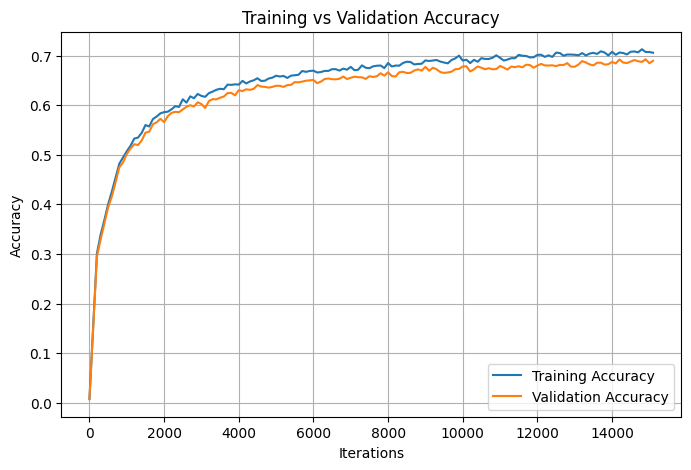

In [ ]:
import matplotlib.pyplot as plt

# Calculate epochs for plotting
epochs = [(i * eval_interval) + (eval_interval if i > 0 else 0) for i in range(len(train_accuracies))]

# Plot Training vs Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, label='Training Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

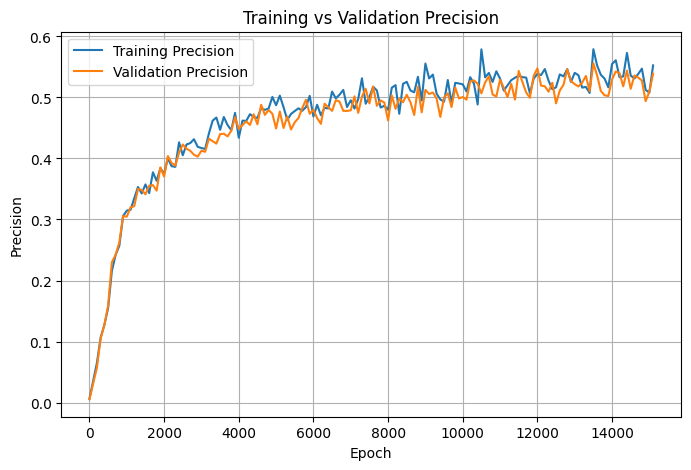

In [ ]:
# -------------------------------------------------------
# 3. Training vs Validation Precision
# -------------------------------------------------------
import matplotlib.pyplot as plt

# Recalculate epochs list to ensure it matches the length of the data
epochs = [(i * eval_interval) + (eval_interval if i > 0 else 0) for i in range(len(train_precisions))]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_precisions, label='Training Precision')
plt.plot(epochs, val_precisions, label='Validation Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.title('Training vs Validation Precision')
plt.legend()
plt.grid(True)
plt.show()

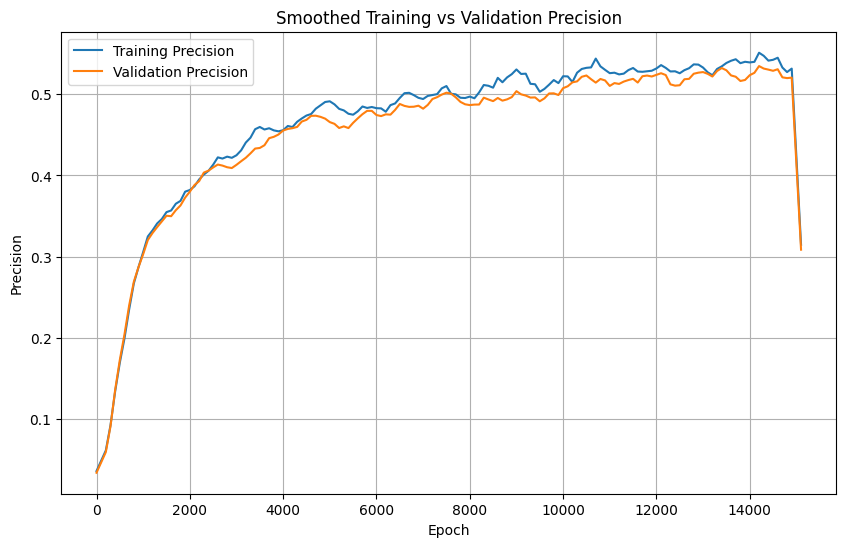

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure epochs is consistently generated
epochs = np.array([(i * eval_interval) + (eval_interval if i > 0 else 0) for i in range(len(train_precisions))])

# Convert to numpy arrays before smoothing
train_precision = np.array(train_precisions)
val_precision = np.array(val_precisions)

# --- Smoothing function ---
def smooth_curve(values, smoothing=5):
    # Ensure smoothing window is not larger than data length
    if smoothing >= len(values):
        # Fallback to no smoothing or smaller smoothing if window too large
        print(f"Warning: Smoothing window ({smoothing}) is too large for data length ({len(values)}). Using no smoothing.")
        return values
    return np.convolve(values, np.ones(smoothing)/smoothing, mode='same')

# Apply smoothing with a smaller, more appropriate window size
# Changed smoothing from 200 to 5
train_precision_smooth = smooth_curve(train_precision, smoothing=5)
val_precision_smooth = smooth_curve(val_precision, smoothing=5)

# Plot smoothed precision
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_precision_smooth, label="Training Precision")
plt.plot(epochs, val_precision_smooth, label="Validation Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Smoothed Training vs Validation Precision")
plt.legend()
plt.grid(True)
plt.show()

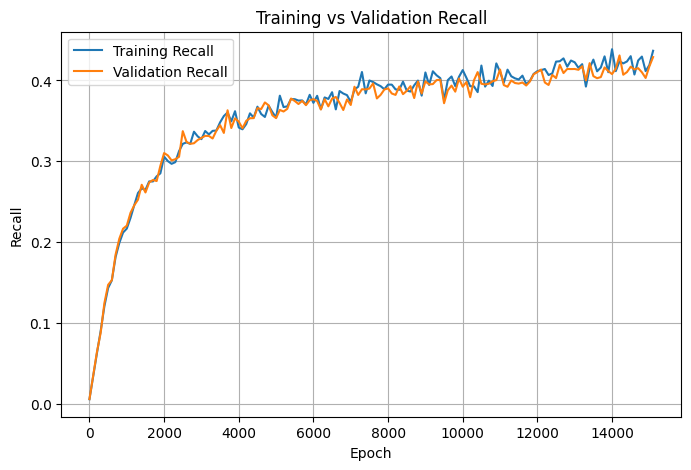

In [ ]:
# -------------------------------------------------------
# 4. Training vs Validation Recall
# -------------------------------------------------------
import matplotlib.pyplot as plt

# Recalculate epochs list to ensure it matches the length of the data
epochs = [(i * eval_interval) + (eval_interval if i > 0 else 0) for i in range(len(train_recalls))]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_recalls, label='Training Recall')
plt.plot(epochs, val_recalls, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall')
plt.legend()
plt.grid(True)
plt.show()

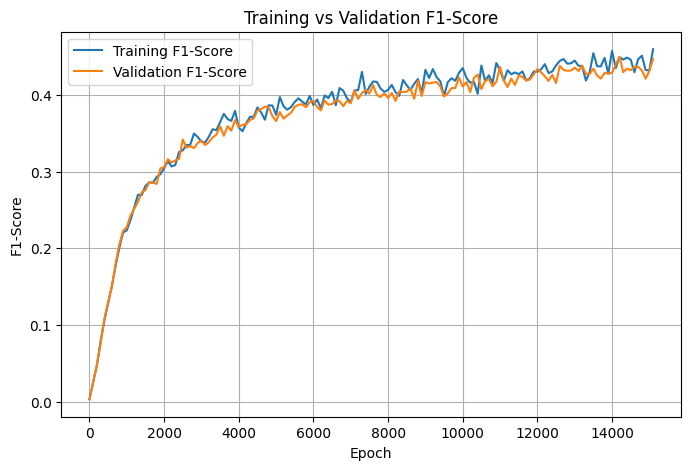

In [ ]:
# -------------------------------------------------------
# 5. Training vs Validation F1-Score
# -------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_f1_scores, label='Training F1-Score')
plt.plot(epochs, val_f1_scores, label='Validation F1-Score')
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.title('Training vs Validation F1-Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from torchinfo import summary

summary(model,
        input_size=(1, block_size),
        dtypes=[torch.long])
for name, param in model.named_parameters():
    print(f"{name:40} | {param.numel():10d} parameters")


token_embedding_table.weight             |       5888 parameters
position_embedding_table.weight          |       2048 parameters
blocks.0.sa.heads.0.key.lora_A           |        256 parameters
blocks.0.sa.heads.0.key.lora_B           |         64 parameters
blocks.0.sa.heads.0.key.linear.weight    |       1024 parameters
blocks.0.sa.heads.0.query.lora_A         |        256 parameters
blocks.0.sa.heads.0.query.lora_B         |         64 parameters
blocks.0.sa.heads.0.query.linear.weight  |       1024 parameters
blocks.0.sa.heads.0.value.lora_A         |        256 parameters
blocks.0.sa.heads.0.value.lora_B         |         64 parameters
blocks.0.sa.heads.0.value.linear.weight  |       1024 parameters
blocks.0.sa.heads.1.key.lora_A           |        256 parameters
blocks.0.sa.heads.1.key.lora_B           |         64 parameters
blocks.0.sa.heads.1.key.linear.weight    |       1024 parameters
blocks.0.sa.heads.1.query.lora_A         |        256 parameters
blocks.0.sa.heads.1.query

In [ ]:
from torchinfo import summary

summary(model, input_size=(1, block_size), dtypes=[torch.long])

Layer (type:depth-idx)                             Output Shape              Param #
BigramLanguageModel                                [1, 32, 92]               --
├─Embedding: 1-1                                   [1, 32, 64]               5,888
├─Embedding: 1-2                                   [32, 64]                  2,048
├─Sequential: 1-3                                  [1, 32, 64]               --
│    └─Block: 2-1                                  [1, 32, 64]               --
│    │    └─LayerNorm: 3-1                         [1, 32, 64]               128
│    │    └─MultiHeadAttention: 3-2                [1, 32, 64]               20,800
│    │    └─LayerNorm: 3-3                         [1, 32, 64]               128
│    │    └─FeedFoward: 3-4                        [1, 32, 64]               35,648
│    └─Block: 2-2                                  [1, 32, 64]               --
│    │    └─LayerNorm: 3-5                         [1, 32, 64]               128
│    │    └─MultiH